In [2]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv('cloud_customer_churn (1).csv')
df.head(20)

FileNotFoundError: [Errno 2] No such file or directory: 'cloud_customer_churn (1).csv'

In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
df.isnull().sum()

In [ ]:
df["Churn"].value_counts()

In [ ]:
numeric_features = [
    "Monthly_Cloud_Spend",
    "Compute_Usage_Hours",
    "Storage_GB",
    "Support_Tickets",
    "Account_Age_Months",
    "Services_Used",
    "Downtime_Hours",
    "Customer_Satisfaction"
]

categorical_features = [
    "Contract_Type",
    "Region",
    "Auto_Renew"
]

In [ ]:
for column in df.columns:
    print(column)
    print(df[column].value_counts())
    print()

In [ ]:
X = df.drop(columns=["Customer_ID", "Churn"])
y = df["Churn"]

In [ ]:

y.shape

In [ ]:
X.shape

In [ ]:
for column in df.columns:
    print(column, df[column].nunique())

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [ ]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [ ]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [ ]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

Because churn is imbalanced, class_weight="balanced" helps the model pay more attention to the smaller Yes class.

In [ ]:
model_pipeline.fit(X_train, y_train)

In [ ]:
y_pred = model_pipeline.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print()

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()

print("Classification Report:")
print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

logistic_pipeline.fit(X_train, y_train)

y_pred_log = logistic_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_log))

In [ ]:
from sklearn.metrics import roc_auc_score

rf_prob = model_pipeline.predict_proba(X_test)[:, 1]
log_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

rf_auc = roc_auc_score(y_test, rf_prob)
log_auc = roc_auc_score(y_test, log_prob)

print("Random Forest ROC-AUC:", rf_auc)
print("Logistic Regression ROC-AUC:", log_auc)

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:

    y_pred_threshold = np.where(
        log_prob >= threshold,
        "Yes",
        "No"
    )

    precision = precision_score(
        y_test,
        y_pred_threshold,
        pos_label="Yes"
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        pos_label="Yes"
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        pos_label="Yes"
    )

    print(
        "Threshold:", threshold,
        "| Precision:", round(precision, 3),
        "| Recall:", round(recall, 3),
        "| F1:", round(f1, 3)
    )

In [ ]:
final_threshold = 0.7

y_pred_final = np.where(
    log_prob >= final_threshold,
    "Yes",
    "No"
)

print(confusion_matrix(y_test, y_pred_final))
print()
print(classification_report(y_test, y_pred_final))

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    logistic_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("CV ROC-AUC scores:", cv_scores)
print("Mean CV ROC-AUC:", cv_scores.mean())
print("Std CV ROC-AUC:", cv_scores.std())

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    logistic_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best C:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)

In [ ]:
best_model = grid_search.best_estimator_

best_prob = best_model.predict_proba(X_test)[:, 1]

print(
    "Test ROC-AUC:",
    roc_auc_score(y_test, best_prob)
)

In [ ]:
import joblib

best_model = grid_search.best_estimator_

joblib.dump(
    best_model,
    "cloud_churn_pipeline.pkl"
)

print("Pipeline saved successfully.")

In [ ]:
loaded_model = joblib.load("cloud_churn_pipeline.pkl")

sample_predictions = loaded_model.predict(X_test.head())

print(sample_predictions)

In [ ]:
loaded_prob = loaded_model.predict_proba(X_test.head())[:, 1]

loaded_pred_07 = np.where(
    loaded_prob >= 0.7,
    "Yes",
    "No"
)

print(loaded_pred_07)

In [ ]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=42,
    stratify=y_train_val
)


In [ ]:
best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        C=0.1,
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

best_model.fit(X_train, y_train)

In [ ]:
val_prob = best_model.predict_proba(X_val)[:, 1]

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

for threshold in np.arange(0.3, 0.81, 0.05):

    val_pred = np.where(
        val_prob >= threshold,
        "Yes",
        "No"
    )

    precision = precision_score(
        y_val,
        val_pred,
        pos_label="Yes"
    )

    recall = recall_score(
        y_val,
        val_pred,
        pos_label="Yes"
    )

    f1 = f1_score(
        y_val,
        val_pred,
        pos_label="Yes"
    )

    print(
        round(threshold, 2),
        "Precision:", round(precision, 3),
        "Recall:", round(recall, 3),
        "F1:", round(f1, 3)
    )

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score
)

test_prob = best_model.predict_proba(X_test)[:, 1]

final_threshold = 0.50

test_pred = np.where(
    test_prob >= final_threshold,
    "Yes",
    "No"
)

print("Accuracy:", accuracy_score(y_test, test_pred))
print("ROC-AUC:", roc_auc_score(y_test, test_prob))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, test_pred))
print()
print("Classification Report:")
print(classification_report(y_test, test_pred))

In [ ]:
final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        C=0.1,
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

final_model.fit(X_train_val, y_train_val)

In [ ]:
import joblib

joblib.dump(
    final_model,
    "cloud_churn_final_pipeline.pkl"
)

In [ ]:
joblib.dump(
    0.50,
    "cloud_churn_threshold.pkl"
)

In [4]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("cloud_customer_churn.csv")

# Features and target
X = df.drop(columns=["Customer_ID", "Churn"])
y = df["Churn"]

# Recreate the same train/test split
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Load saved final model
final_model = joblib.load("cloud_churn_final_pipeline.pkl")

# Probabilities
test_prob = final_model.predict_proba(X_test)[:, 1]

# Final threshold
threshold = 0.50

test_pred = np.where(
    test_prob >= threshold,
    "Yes",
    "No"
)

print("Variables recreated successfully.")

Variables recreated successfully.


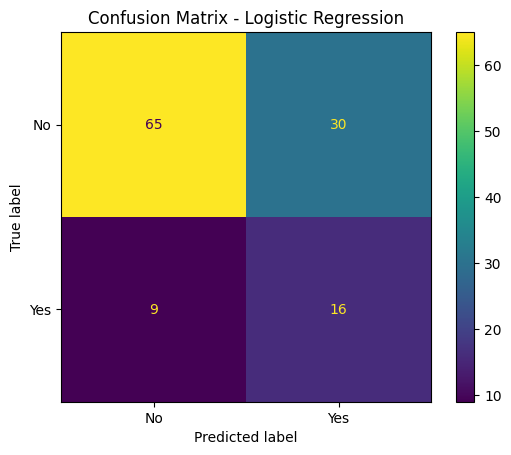

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred
)

plt.title("Confusion Matrix - Logistic Regression")
plt.savefig("confusion_matrix.png", bbox_inches="tight")
plt.show()

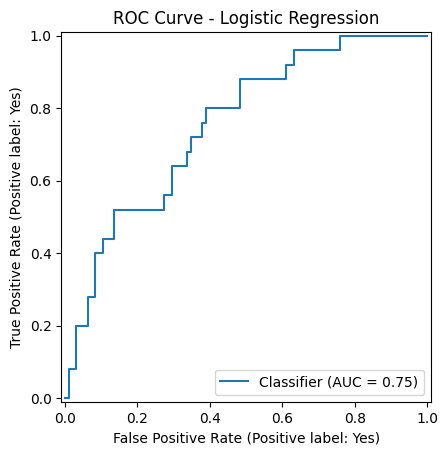

In [7]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(
    y_test,
    test_prob,
    pos_label="Yes"
)

plt.title("ROC Curve - Logistic Regression")
plt.savefig("roc_curve.png", bbox_inches="tight")
plt.show()

In [8]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, test_pred))
print("ROC-AUC:", roc_auc_score(y_test, test_prob))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, test_pred))
print()
print(classification_report(y_test, test_pred))

Accuracy: 0.675
ROC-AUC: 0.7536842105263157

Confusion Matrix:
[[65 30]
 [ 9 16]]

              precision    recall  f1-score   support

          No       0.88      0.68      0.77        95
         Yes       0.35      0.64      0.45        25

    accuracy                           0.68       120
   macro avg       0.61      0.66      0.61       120
weighted avg       0.77      0.68      0.70       120

